In [157]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

from scipy import stats

In [158]:
df = pd.read_csv("data.csv", sep=';')
df = df.iloc[1:]
df = df.reset_index(drop=True)
df.columns = [
    'time',
    'global_radiation',
    'temperature',
    'humidity',
    'irrigation',
    'irrigation_time',
    'rain_water',
    'drain'
]

# Konversi Kolom "Time" tipe data datetime
df['time'] = pd.to_datetime(df['time'], dayfirst=True)

cols = ['global_radiation', 'temperature', 'humidity',
        'irrigation', 'irrigation_time', 'rain_water', 'drain']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().reset_index(drop=True)

print("Jumlah data awal:", len(df))
print("\nContoh data awal:")
print(df.head())

Jumlah data awal: 2508

Contoh data awal:
                 time  global_radiation  temperature  humidity  irrigation  \
0 2016-05-30 00:00:00                 0         19.4      91.4           0   
1 2016-05-30 00:05:00                 1         19.4      90.8           0   
2 2016-05-30 00:10:00                 0         19.3      91.3           0   
3 2016-05-30 00:15:00                 0         19.5      91.0           0   
4 2016-05-30 00:20:00                 0         19.5      91.0           0   

   irrigation_time  rain_water  drain  
0             22.0           0      0  
1             22.0           0      0  
2             22.0           0      0  
3             22.0           0      0  
4             22.0           0      0  


In [159]:
# =========================
# 2. FEATURE ENGINEERING TIME
# =========================
df['hour'] = df['time'].dt.hour
df['day'] = df['time'].dt.day
df['month'] = df['time'].dt.month   

Penanganan Outlier

In [160]:
# print(df.head())
df['Z-Score'] = np.abs(stats.zscore(df['humidity']))
outliers = df[df['Z-Score'] > 3]
print("Data Outlier:")
print(outliers[['time', 'humidity', 'Z-Score']])

Data Outlier:
                    time  humidity   Z-Score
2226 2016-06-06 17:35:00      48.2  3.030106
2229 2016-06-06 17:50:00      48.3  3.021179
2230 2016-06-06 17:55:00      48.0  3.047960
2231 2016-06-06 18:00:00      48.0  3.047960
2233 2016-06-06 18:10:00      47.8  3.065815
2236 2016-06-06 18:25:00      48.3  3.021179
2237 2016-06-06 18:30:00      47.6  3.083669
2239 2016-06-06 18:40:00      46.7  3.164014
2240 2016-06-06 18:45:00      47.4  3.101524
2487 2016-06-07 15:20:00      47.8  3.065815
2497 2016-06-07 16:10:00      48.3  3.021179
2499 2016-06-07 16:20:00      42.3  3.556813
2500 2016-06-07 16:25:00      45.9  3.235432
2502 2016-06-07 16:35:00      43.8  3.422904
2503 2016-06-07 16:40:00      46.5  3.181869
2504 2016-06-07 16:45:00      48.5  3.003324
2505 2016-06-07 16:50:00      45.1  3.306850
2507 2016-06-07 17:00:00      44.7  3.342559


In [161]:
print("Jumlah outlier:", len(outliers))

Jumlah outlier: 18


In [162]:
df_clean = df[df['Z-Score'] <= 3].copy()
print("Jumlah data setelah cleaning:", len(df_clean))

Jumlah data setelah cleaning: 2490


In [163]:
print("Sebelum:", len(df))
print("Sesudah:", len(df_clean))

Sebelum: 2508
Sesudah: 2490


XGBoost

In [164]:
from xgboost import XGBRegressor

In [165]:
df_model = df_clean.copy()

In [166]:
outlier_summary = []

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_before = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    outlier_count = len(outliers_before)

    outlier_summary.append({
        'feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower,
        'upper_bound': upper,
        'jumlah_outlier': outlier_count
    })

    # Clipping agar nilai ekstrem dibatasi, bukan dihapus
    df_clean[col] = df_clean[col].clip(lower, upper)

# Ringkasan outlier
outlier_summary_df = pd.DataFrame(outlier_summary)

print("\n=== Ringkasan Outlier ===")
print(outlier_summary_df[['feature', 'lower_bound', 'upper_bound', 'jumlah_outlier']])

print("\nContoh data setelah cleaning:")
print(df_clean.head())

# Simpan data cleaning
df_clean.to_csv("data_clean.csv", index=False)
print("\nData cleaning disimpan ke: data_clean.csv")


=== Ringkasan Outlier ===
            feature  lower_bound  upper_bound  jumlah_outlier
0  global_radiation    -574.6250     960.3750               0
1       temperature      14.6000      30.6000               2
2          humidity      51.0125     114.5125              19
3        irrigation   -2398.0000    5874.0000               0
4   irrigation_time     -34.0000      70.0000               0
5        rain_water   -3303.5000    7124.5000               0
6             drain    -748.5000    1759.5000               0

Contoh data setelah cleaning:
                 time  global_radiation  temperature  humidity  irrigation  \
0 2016-05-30 00:00:00                 0         19.4      91.4           0   
1 2016-05-30 00:05:00                 1         19.4      90.8           0   
2 2016-05-30 00:10:00                 0         19.3      91.3           0   
3 2016-05-30 00:15:00                 0         19.5      91.0           0   
4 2016-05-30 00:20:00                 0         19.5    

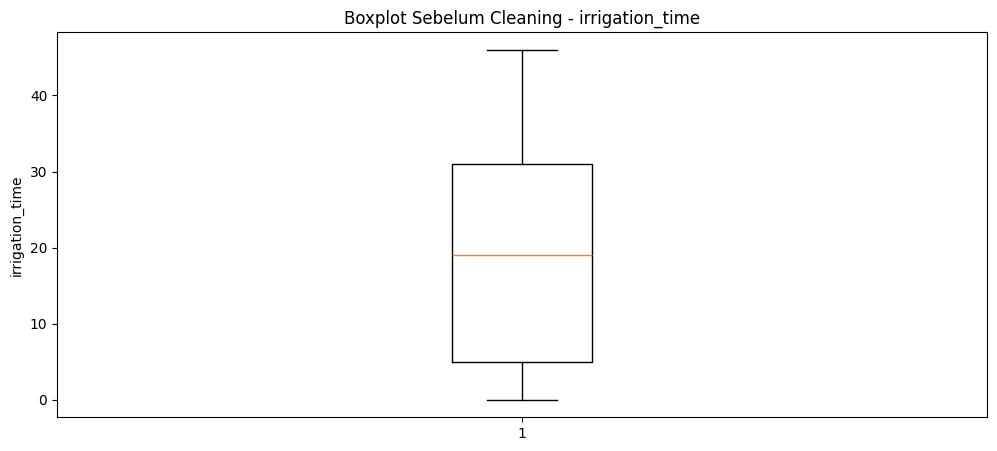

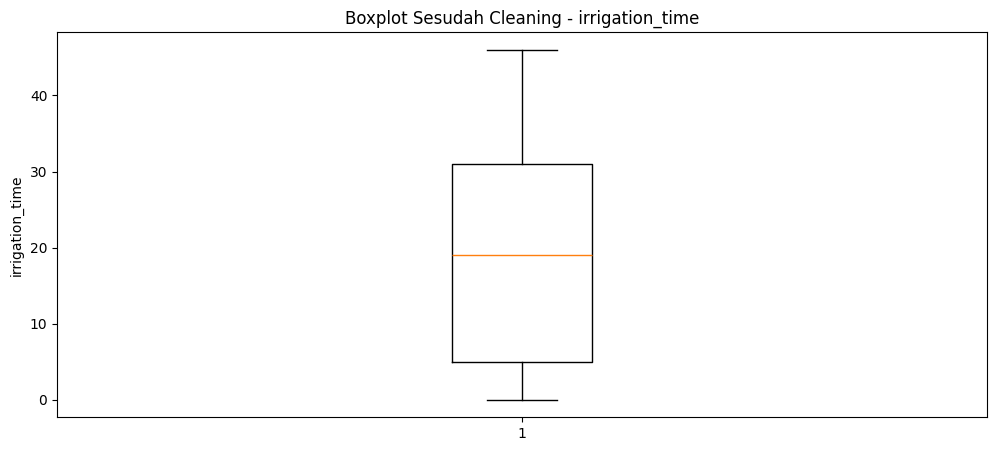

In [167]:
# =========================================================
# 5. VISUALISASI SEBELUM vs SESUDAH CLEANING
# =========================================================
feature_to_plot = 'irrigation_time'   # bisa diganti: 'humidity', 'temperature', dll

plt.figure(figsize=(12, 5))
plt.boxplot(df[feature_to_plot].dropna())
plt.title(f"Boxplot Sebelum Cleaning - {feature_to_plot}")
plt.ylabel(feature_to_plot)
plt.show()

plt.figure(figsize=(12, 5))
plt.boxplot(df_clean[feature_to_plot].dropna())
plt.title(f"Boxplot Sesudah Cleaning - {feature_to_plot}")
plt.ylabel(feature_to_plot)
plt.show()


In [168]:
df_model = df_clean.copy()
df_model['irrigation_diff'] = df_model['irrigation'].diff()
df_model['lag1'] = df_model['irrigation'].shift(1)
df_model['lag2'] = df_model['irrigation'].shift(2)
df_model['lag3'] = df_model['irrigation'].shift(3)
df_model['lag4'] = df_model['irrigation'].shift(4)
df_model['lag5'] = df_model['irrigation'].shift(5)

df_model['lag6'] = df_model['irrigation_diff'].shift(6)
df_model['lag7'] = df_model['irrigation_diff'].shift(7)
df_model['lag8'] = df_model['irrigation_diff'].shift(8)

df_model['rolling_mean_3'] = df_model['irrigation'].rolling(3).mean()
df_model['rolling_mean_5'] = df_model['irrigation'].rolling(5).mean()
df_model['rolling_mean_10'] = df_model['irrigation_diff'].rolling(10).mean()

df_model['rolling_std_5'] = df_model['irrigation_diff'].rolling(5).std()
df_model['diff2'] = df_model['irrigation_diff'].diff(1)

df_model['rolling_max_5'] = df_model['irrigation_diff'].rolling(5).max()
df_model['rolling_min_5'] = df_model['irrigation_diff'].rolling(5).min()

df_model = df_model.dropna().reset_index(drop=True)
print("\nJumlah data untuk modeling:", len(df_model))
print(df_model.head())


Jumlah data untuk modeling: 2480
                 time  global_radiation  temperature  humidity  irrigation  \
0 2016-05-30 00:50:00                 0         19.4      92.3           0   
1 2016-05-30 00:55:00                 1         19.4      92.0           0   
2 2016-05-30 01:00:00                 0         19.3      92.3           0   
3 2016-05-30 01:05:00                 0         19.3      92.3           0   
4 2016-05-30 01:10:00                 1         19.2      92.5           0   

   irrigation_time  rain_water  drain  hour  day  ...  lag6  lag7  lag8  \
0             22.0           0      0     0   30  ...   0.0   0.0   0.0   
1             22.0           0      0     0   30  ...   0.0   0.0   0.0   
2             22.0           0      0     1   30  ...   0.0   0.0   0.0   
3             22.0           0      0     1   30  ...   0.0   0.0   0.0   
4             22.0           0      0     1   30  ...   0.0   0.0   0.0   

   rolling_mean_3  rolling_mean_5  rolling_mea

In [169]:
X = df_model[
    [
        'global_radiation',
        'temperature',
        'humidity',
        'irrigation_time',
        'rain_water',
        'hour',
        'day',
        'month',
        'lag1',
        'lag2',
        'lag3',
        'lag4',
        'lag5',
        'lag6',
        'lag7',
        'lag8',
        'rolling_mean_3',
        'rolling_mean_5',
        'rolling_mean_10',
        'rolling_std_5',
        'rolling_max_5',
        'rolling_min_5',
        'diff2'
    ]
]

y = df_model['irrigation_diff']

print("\nUkuran data:")
print("X shape:", X.shape)
print("y shape:", y.shape)


Ukuran data:
X shape: (2480, 23)
y shape: (2480,)


In [170]:
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nData train:", X_train.shape, y_train.shape)
print("Data test :", X_test.shape, y_test.shape)


Data train: (1984, 23) (1984,)
Data test : (496, 23) (496,)


In [171]:
model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='reg:squarederror',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=None, num_parallel_tree=None, ...)

In [172]:
y_pred = model.predict(X_test)

In [173]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nHasil Evaluasi XGBoost")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)


Hasil Evaluasi XGBoost
MSE  : 4.10308895822488
RMSE : 2.0256082933837134
MAE  : 0.4080822025118264
R2   : 0.9387229879778531


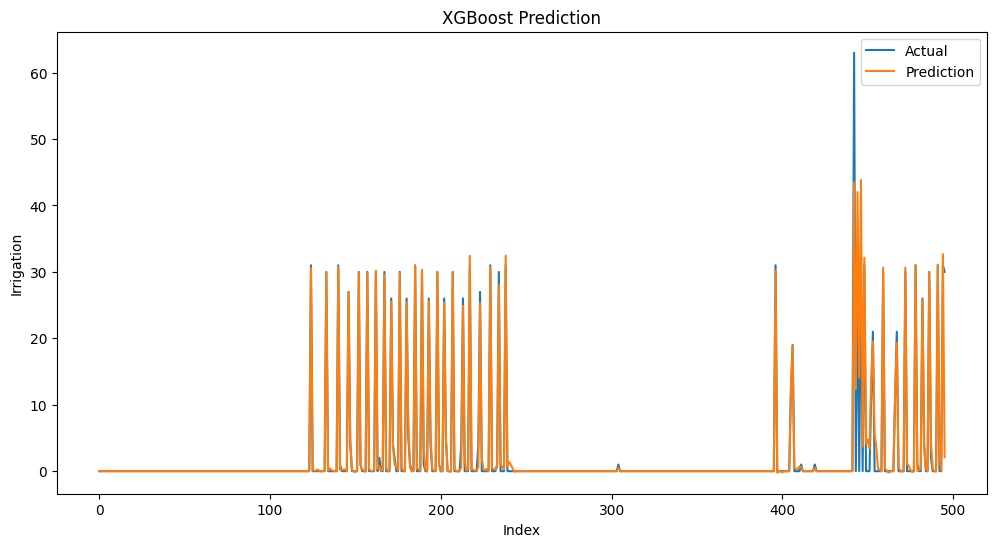

In [174]:
# =========================================================
# 12. VISUALISASI ACTUAL VS PREDICTION
# =========================================================
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Prediction')
plt.title("XGBoost Prediction")
plt.xlabel("Index")
plt.ylabel("Irrigation")
plt.legend()
plt.show()